In [1]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
import os

import sys
sys.path.append('../../')
import analysis_utils as utils

utils.load_plotting_setting()

In [2]:
import importlib
importlib.reload(utils)

<module 'analysis_utils' from '/Users/yuhan/work/nanospheres/gas_collisiions/analysis_notebooks/sphere_20260215_final_analysis/../../analysis_utils.py'>

In [13]:
import glob
from scipy.optimize import curve_fit

# ── Parameters — must match process_gas_data.py ───────────────────────────
bandpass_lb        = 35000
bandpass_ub        = 80000
lowpass_order      = 3
notch_freq         = 137000
c_imp_scaling      = 1 / 3
positive_pulse     = True

fit_window_length      = 2**19   # prepulse window for ω₀ estimation
analysis_window_length = 2**18   # window centred on each pulse for reconstruction
search_window_length   = 2**8    # search window for peak amplitude
pulse_length           = 20      # offset inside search window
waveform_half_len      = 1500    # samples on each side of peak to store (~60 µs)

# Fixed reconstruction parameters. Set to a float to pin to a constant for all
# files instead of using the per-file Voigt fit result.
# Set to None to use the per-file fit (default behaviour).
fixed_gamma_damping = 1 * 2 * np.pi   # rad/s, e.g. 200 * 2 * np.pi
fixed_c_imp         = 1.5e-22   # raw units; bypasses c_imp_voigt × c_imp_scaling entirely

expected_kev = 1046              # 20 V calibration result

# ── All xenon datasets ─────────────────────────────────────────────────────
xe_datasets = [
    ('20260219_p6e_1e-6mbar',   '1e-6 mbar'),
    ('20260219_p6e_8e-7mbar',   '8e-7 mbar'),
    # # ('20260219_p6e_4e-7mbar',   '4e-7 mbar'),
    ('20260219_p6e_4e-7mbar_1', '4e-7 mbar (2)'),
    ('20260219_p6e_2e-7mbar',   '2e-7 mbar'),
    # # ('20260219_p6e_1e-7mbar',   '1e-7 mbar'),
    ('20260219_p6e_1e-7mbar_1', '1e-7 mbar (2)'),
    ('20260219_p6e_7e-8mbar',   '7e-8 mbar'),
    ('20260219_p6e_5e-8mbar',   '5e-8 mbar'),
]
raw_base = r'/Volumes/LaCie/gas_collisions/xenon_data/sphere_20260215'
n_files  = 5   # raw files to process per dataset

# The pulse sits at analysis_window_length inside amp_lp (from get_analysis_window).
# Restrict the peak search to the same region recon_pulse searches, so gas
# collisions or edge artefacts elsewhere in the 524288-sample array don't win.
_search_lo = analysis_window_length + pulse_length
_search_hi = _search_lo + search_window_length

# ── Reconstruct cal pulses from raw data ──────────────────────────────────
all_amps      = {ds: [] for ds, _ in xe_datasets}   # raw amplitude units
all_waveforms = {ds: [] for ds, _ in xe_datasets}   # raw amplitude units

for dataset, label in xe_datasets:
    data_dir = os.path.join(raw_base, dataset)
    files    = sorted(glob.glob(os.path.join(data_dir, '20260219_dfg_*.hdf5')))[:n_files]
    print(f'\n{label}  ({len(files)} files)')

    for fpath in files:
        dtt, nn  = utils.load_timestreams(fpath, ['D', 'G'])
        fs       = int(np.ceil(1 / dtt))
        zz, dd   = nn[0], nn[1]

        if fixed_gamma_damping is not None and fixed_c_imp is not None:
            gamma_damping = fixed_gamma_damping
            c_imp = fixed_c_imp
            omega0 = None
        else:
            p_fit, sv_imp, _, _ = utils.get_sv_imp(
                fs, zz, fit_band=(44000, 60000), noise_band=(110000, 120000),
                nperseg=2**19, p0=[5e-3, 48381*2*np.pi, 100*2*np.pi, 1*2*np.pi])
            A, omega0, sigma, gamma_v = p_fit
            gamma_damping = gamma_v * 2
            c_imp = (np.pi / (omega0**2 * gamma_damping)) * sv_imp / A * c_imp_scaling
            if fixed_gamma_damping is not None:
                gamma_damping = fixed_gamma_damping
            if fixed_c_imp is not None:
                c_imp = fixed_c_imp

        zz_notched = utils.notch_filtered(zz, fs, f0=notch_freq, q=50)
        zz_bp      = utils.bandpass_filtered(zz_notched, fs, bandpass_lb, bandpass_ub,
                                             order=lowpass_order)

        pulse_indices = utils.get_pulse_idx(dd, 0.5 * positive_pulse, positive_pulse)
        f0_str = f'f₀={omega0/(2*np.pi)/1e3:.3f} kHz, ' if omega0 is not None else ''
        print(f'  {os.path.basename(fpath)}: {len(pulse_indices)} triggers, '
              f'{f0_str}γ={gamma_damping/(2*np.pi):.2f} Hz, '
              f'c_imp={c_imp:.3e}')

        for idx in pulse_indices:
            _, _, amp_lp, amp = utils.recon_pulse(
                idx, dtt, zz_bp, dd,
                c_imp=c_imp, gamma_damping=gamma_damping,
                analysis_window_length=analysis_window_length,
                prepulse_window_length=fit_window_length,
                search_window_length=search_window_length,
                pulse_length=pulse_length,
                lowpass_freq=bandpass_ub,
                lowpass_order=lowpass_order)
            if np.isnan(amp):
                continue

            all_amps[dataset].append(amp)   # raw units — converted to keV in next cell

            # Find peak only within the calibration pulse search region, so that
            # gas collisions or filter edge artefacts elsewhere don't shift the centre.
            peak_i   = _search_lo + np.argmax(np.abs(amp_lp[_search_lo:_search_hi]))
            polarity = 1 if amp_lp[peak_i] > 0 else -1
            lo, hi   = peak_i - waveform_half_len, peak_i + waveform_half_len
            if lo >= 0 and hi <= amp_lp.size:
                all_waveforms[dataset].append(polarity * amp_lp[lo:hi])   # raw units


1e-6 mbar  (5 files)
  20260219_dfg_0.hdf5: 23 triggers, γ=1.00 Hz, c_imp=1.500e-22
Skipping pulse too close to the beginning of the file
  20260219_dfg_1.hdf5: 22 triggers, γ=1.00 Hz, c_imp=1.500e-22
  20260219_dfg_10.hdf5: 22 triggers, γ=1.00 Hz, c_imp=1.500e-22
  20260219_dfg_11.hdf5: 22 triggers, γ=1.00 Hz, c_imp=1.500e-22
  20260219_dfg_12.hdf5: 23 triggers, γ=1.00 Hz, c_imp=1.500e-22
Skipping pulse too close to the beginning of the file

8e-7 mbar  (5 files)
  20260219_dfg_0.hdf5: 23 triggers, γ=1.00 Hz, c_imp=1.500e-22
Skipping pulse too close to the beginning of the file
  20260219_dfg_1.hdf5: 22 triggers, γ=1.00 Hz, c_imp=1.500e-22
  20260219_dfg_10.hdf5: 22 triggers, γ=1.00 Hz, c_imp=1.500e-22
  20260219_dfg_11.hdf5: 23 triggers, γ=1.00 Hz, c_imp=1.500e-22
Skipping pulse too close to the beginning of the file
  20260219_dfg_12.hdf5: 23 triggers, γ=1.00 Hz, c_imp=1.500e-22
Skipping pulse too close to the beginning of the file

4e-7 mbar (2)  (5 files)
  20260219_dfg_0.hdf5: 2

1e-6 mbar: amp2kev = 10628.92  (n=110)
8e-7 mbar: amp2kev = 10544.11  (n=110)
4e-7 mbar (2): amp2kev = 11064.03  (n=110)
2e-7 mbar: amp2kev = 10511.46  (n=110)
1e-7 mbar (2): amp2kev = 10779.22  (n=110)
7e-8 mbar: amp2kev = 11293.27  (n=110)
5e-8 mbar: amp2kev = 10632.38  (n=110)


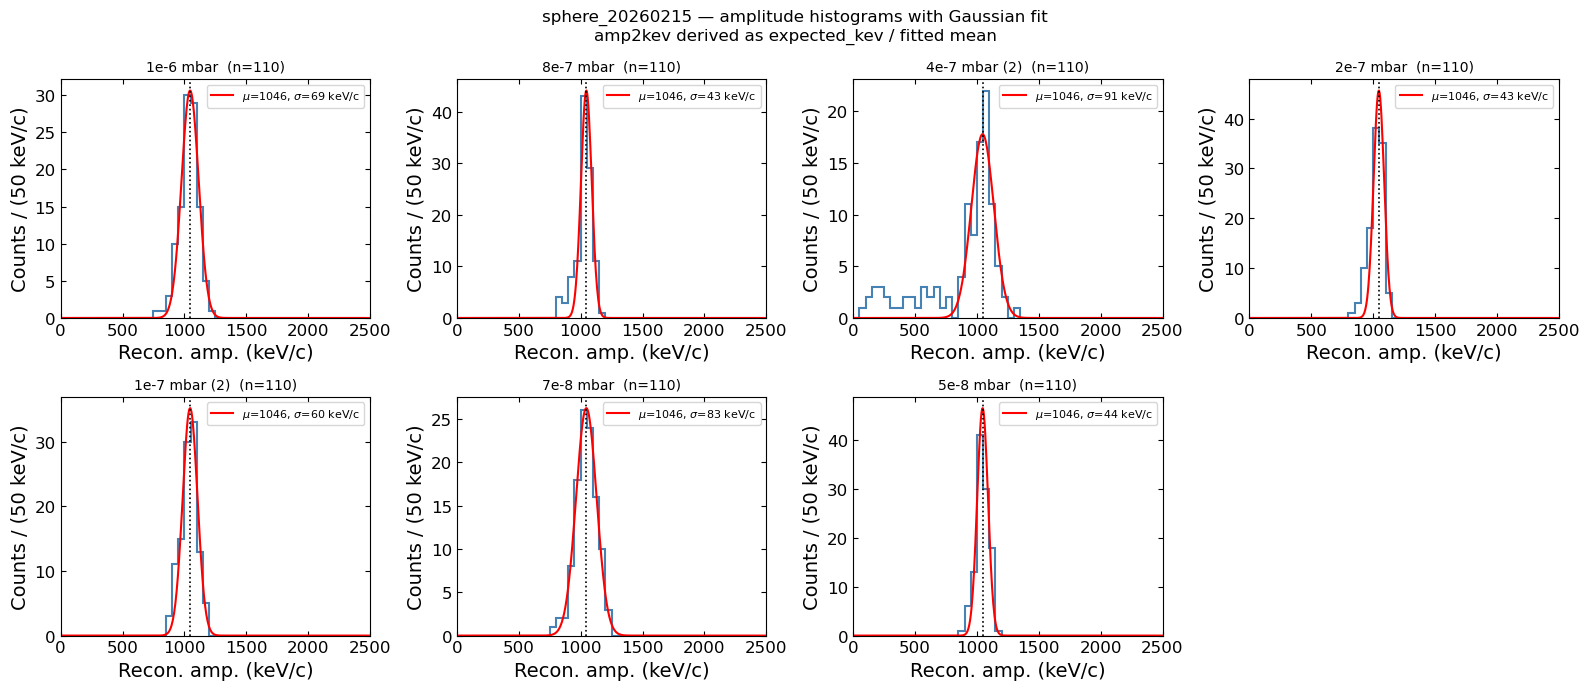

In [14]:
# ── Gaussian fit → amp2kev calibration factor per dataset ─────────────────
# Fit a Gaussian to the raw-amplitude histogram, then derive:
#   amp2kev = expected_kev / fitted_mean
# so that all_amps * amp2kev gives keV/c values centred on expected_kev.

sphere = 'sphere_20260215'
amp2kev = {}   # dataset → calibration factor (keV / raw_amp)

n_cols = 4
n_rows = int(np.ceil(len(xe_datasets) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3.5 * n_rows))
axes_flat  = axes.flatten()

_tt_us = np.linspace(-waveform_half_len, waveform_half_len, 2 * waveform_half_len) / 5e6 * 1e6

for ax, (dataset, label) in zip(axes_flat, xe_datasets):
    amps_raw = np.asarray(all_amps[dataset])
    a2k = None

    if amps_raw.size > 5:
        bins_raw = np.linspace(0, np.max(amps_raw) * 1.3, 60)
        bc_raw   = 0.5 * (bins_raw[:-1] + bins_raw[1:])
        hh_raw, _ = np.histogram(amps_raw, bins=bins_raw)
        try:
            gp, _ = curve_fit(utils.gauss, bc_raw, hh_raw,
                               p0=[hh_raw.max(), np.mean(amps_raw), np.std(amps_raw)],
                               bounds=([0, 0, 0], np.inf), maxfev=10000)
            a2k = expected_kev / gp[1]
        except Exception as e:
            print(f'{label}: Gaussian fit failed ({e})')

    amp2kev[dataset] = a2k

    if a2k is not None:
        amps_kev = amps_raw * a2k
        bins_kev = np.arange(0, 2500, 50)
        bc_kev   = 0.5 * (bins_kev[:-1] + bins_kev[1:])
        hh_kev, _ = np.histogram(amps_kev, bins=bins_kev)
        ax.stairs(hh_kev, edges=bins_kev, color='steelblue', lw=1.5)
        # Replot Gaussian fit in keV/c
        xx = np.linspace(0, 2500, 500)
        dbin_raw = bins_raw[1] - bins_raw[0]
        dbin_kev = 50 / a2k
        ax.plot(xx, utils.gauss(xx / a2k, *gp) * (dbin_kev / dbin_raw),
                'r-', lw=1.5,
                label=fr'$\mu$={gp[1]*a2k:.0f}, $\sigma$={gp[2]*a2k:.0f} keV/c')
        ax.legend(fontsize=8)
        print(f'{label}: amp2kev = {a2k:.2f}  (n={amps_raw.size})')
    else:
        print(f'{label}: fit failed or no data  (n={amps_raw.size})')

    ax.axvline(expected_kev, color='k', ls=':', lw=1.2, label=f'{expected_kev} keV/c')
    ax.set_title(f'{label}  (n={amps_raw.size})', fontsize=10)
    ax.set_xlabel('Recon. amp. (keV/c)')
    ax.set_ylabel('Counts / (50 keV/c)')
    ax.set_xlim(0, 2500)

for ax in axes_flat[len(xe_datasets):]:
    ax.set_visible(False)

fig.suptitle(f'{sphere} — amplitude histograms with Gaussian fit\n'
             f'amp2kev derived as expected_kev / fitted mean', fontsize=12)
fig.tight_layout()
plt.show()

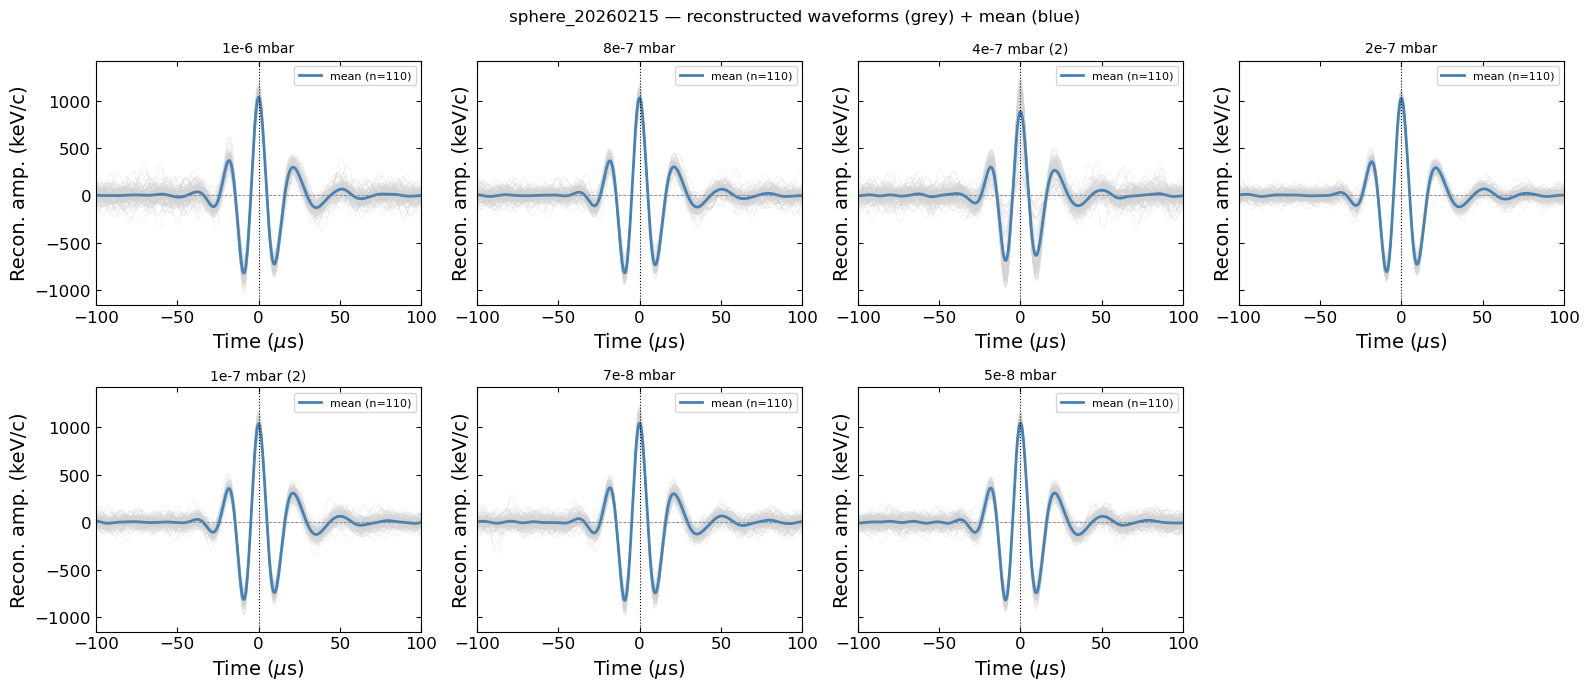

In [15]:
# ── Reconstructed waveforms per dataset ───────────────────────────────────
tt_us = np.arange(-waveform_half_len, waveform_half_len) / 5e6 * 1e6  # µs

n_cols = 4
n_rows = int(np.ceil(len(xe_datasets) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3.5 * n_rows), sharey=True)
axes_flat  = axes.flatten()

for ax, (dataset, label) in zip(axes_flat, xe_datasets):
    wavs_raw = np.asarray(all_waveforms[dataset])
    a2k = amp2kev.get(dataset)

    if wavs_raw.ndim == 2 and wavs_raw.shape[0] > 0 and a2k is not None:
        wavs_kev = wavs_raw * a2k
        for w in wavs_kev:
            ax.plot(tt_us, w, color='lightgray', lw=0.5, alpha=0.4)
        ax.plot(tt_us, wavs_kev.mean(axis=0), color='steelblue', lw=2,
                label=f'mean (n={wavs_kev.shape[0]})')
        ax.legend(fontsize=8)
    else:
        ax.text(0.5, 0.5, 'no data', transform=ax.transAxes,
                ha='center', va='center', color='gray')

    ax.axhline(0, color='gray', ls='--', lw=0.6)
    ax.axvline(0, color='k',    ls=':',  lw=0.8)
    ax.set_xlim(-100, 100)
    ax.set_title(label, fontsize=10)
    ax.set_xlabel(r'Time ($\mu$s)')
    ax.set_ylabel('Recon. amp. (keV/c)')

for ax in axes_flat[len(xe_datasets):]:
    ax.set_visible(False)

fig.suptitle(f'{sphere} — reconstructed waveforms (grey) + mean (blue)', fontsize=12)
fig.tight_layout()
plt.show()

Loading files…
  20260219_dfg_0.hdf5: 23 triggers
  20260219_dfg_1.hdf5: 23 triggers
  20260219_dfg_10.hdf5: 22 triggers
  20260219_dfg_11.hdf5: 22 triggers
  20260219_dfg_12.hdf5: 22 triggers
Skipping pulse too close to the beginning of the file
Skipping pulse too close to the beginning of the file
  c_imp × 0.333 = 3.333e-23: 110 pulses, amp2kev = 8410
Skipping pulse too close to the beginning of the file
Skipping pulse too close to the beginning of the file
  c_imp × 0.5 = 5.000e-23: 110 pulses, amp2kev = 8824
Skipping pulse too close to the beginning of the file
Skipping pulse too close to the beginning of the file
  c_imp × 1 = 1.000e-22: 110 pulses, amp2kev = 9837
Skipping pulse too close to the beginning of the file
Skipping pulse too close to the beginning of the file
  c_imp × 1.5 = 1.500e-22: 110 pulses, amp2kev = 10632
Skipping pulse too close to the beginning of the file
Skipping pulse too close to the beginning of the file
  c_imp × 2 = 2.000e-22: 110 pulses, amp2kev = 113

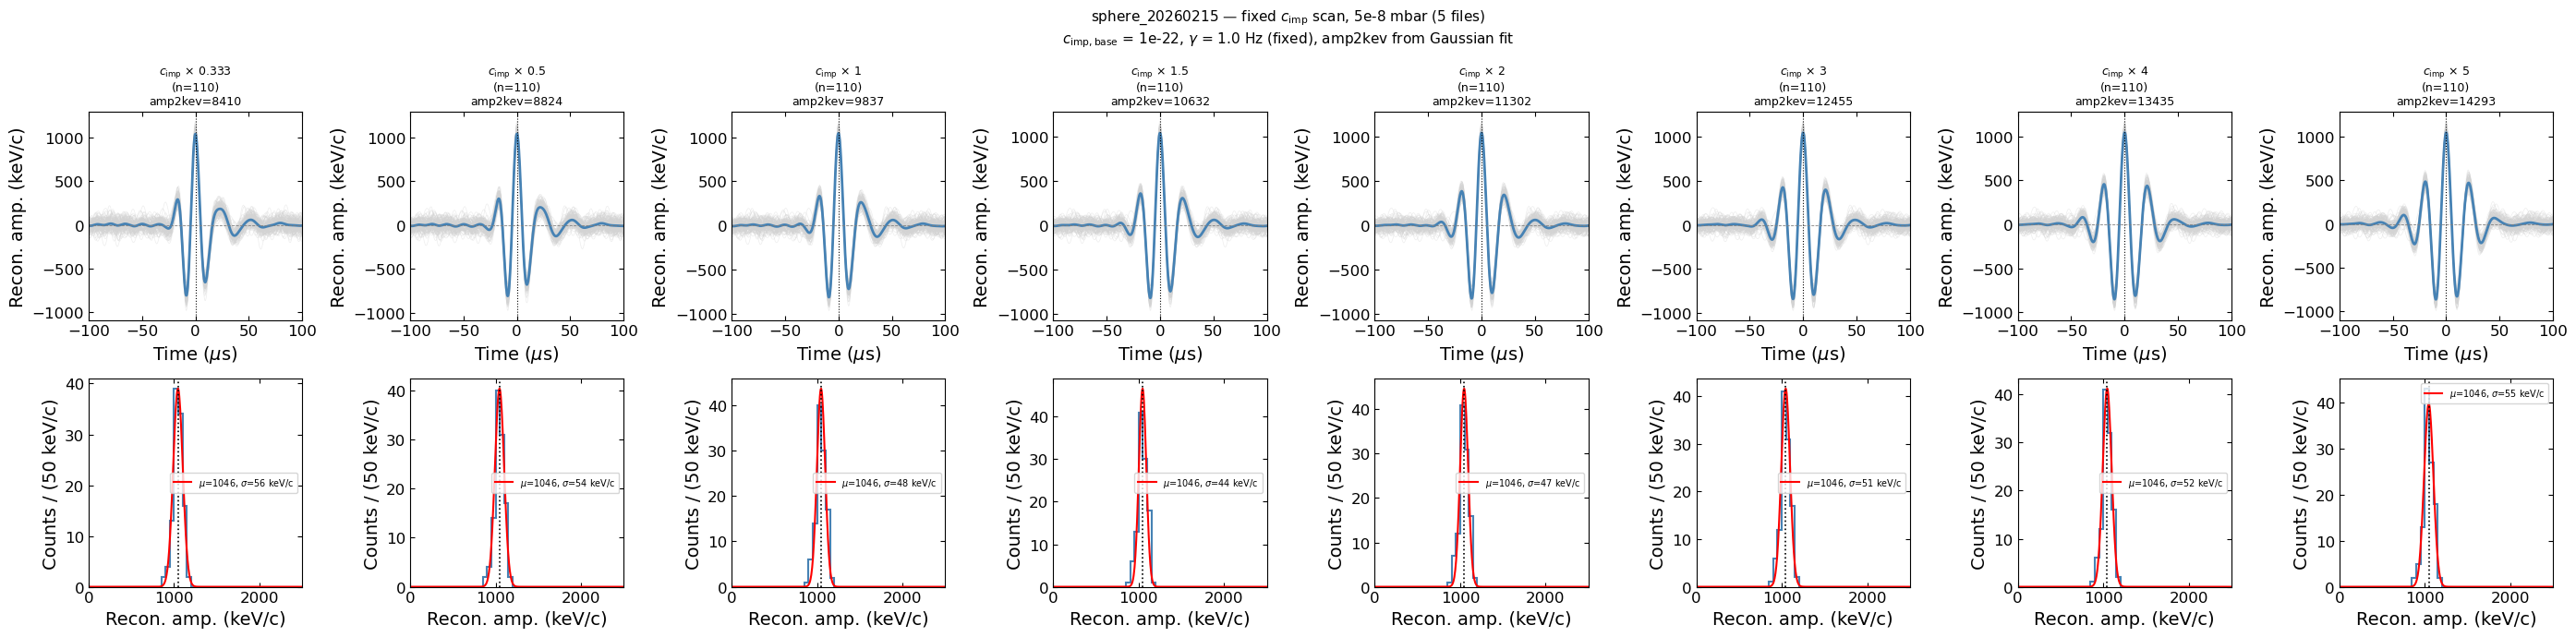

In [12]:
# ── Fixed c_imp scan — 5e-8 mbar dataset ──────────────────────────────────
_scan_dataset   = '20260219_p6e_5e-8mbar'
_scan_label     = '5e-8 mbar'
_scan_n_files   = 5
_c_imp_scalings = [1/3, 1/2, 1, 1.5, 2, 3, 4, 5]   # × _c_imp_base
_c_imp_base     = 1e-22
_gamma_damping  = 1 * 2 * np.pi   # rad/s (1 Hz, fixed)

_data_dir = os.path.join(raw_base, _scan_dataset)
_files    = sorted(glob.glob(os.path.join(_data_dir, '20260219_dfg_*.hdf5')))[:_scan_n_files]

# ── Step 1: Load, filter, find pulse indices (no Voigt fit) ───────────────
print('Loading files…')
_preproc = []
for _fpath in _files:
    _dtt, _nn = utils.load_timestreams(_fpath, ['D', 'G'])
    _fs       = int(np.ceil(1 / _dtt))
    _zz, _dd  = _nn[0], _nn[1]

    _zz_notched = utils.notch_filtered(_zz, _fs, f0=notch_freq, q=50)
    _zz_bp      = utils.bandpass_filtered(_zz_notched, _fs, bandpass_lb, bandpass_ub,
                                          order=lowpass_order)
    _pulse_idx  = utils.get_pulse_idx(_dd, 0.5 * positive_pulse, positive_pulse)
    _preproc.append(dict(zz_bp=_zz_bp, dd=_dd, dtt=_dtt, pulse_indices=_pulse_idx))
    print(f'  {os.path.basename(_fpath)}: {len(_pulse_idx)} triggers')

# ── Step 2: Reconstruct for each fixed c_imp ──────────────────────────────
_scan_results = []

for _scaling in _c_imp_scalings:
    _c_imp_fixed = _c_imp_base * _scaling
    _amps_raw, _wavs_raw = [], []

    for _fp in _preproc:
        for _idx in _fp['pulse_indices']:
            _, _, _amp_lp, _amp = utils.recon_pulse(
                _idx, _fp['dtt'], _fp['zz_bp'], _fp['dd'],
                c_imp=_c_imp_fixed, gamma_damping=_gamma_damping,
                analysis_window_length=analysis_window_length,
                prepulse_window_length=fit_window_length,
                search_window_length=search_window_length,
                pulse_length=pulse_length,
                lowpass_freq=bandpass_ub,
                lowpass_order=lowpass_order)
            if np.isnan(_amp):
                continue
            _amps_raw.append(_amp)
            _peak_i   = _search_lo + np.argmax(np.abs(_amp_lp[_search_lo:_search_hi]))
            _polarity = 1 if _amp_lp[_peak_i] > 0 else -1
            _lo, _hi  = _peak_i - waveform_half_len, _peak_i + waveform_half_len
            if _lo >= 0 and _hi <= _amp_lp.size:
                _wavs_raw.append(_polarity * _amp_lp[_lo:_hi])

    _amps_raw = np.asarray(_amps_raw)
    _wavs_raw = np.asarray(_wavs_raw)

    # Gaussian fit in raw units → amp2kev
    _a2k, _gp, _bins_raw = None, None, None
    if _amps_raw.size > 5:
        _bins_raw = np.linspace(0, np.max(_amps_raw) * 1.3, 60)
        _bc_raw   = 0.5 * (_bins_raw[:-1] + _bins_raw[1:])
        _hh_raw, _ = np.histogram(_amps_raw, bins=_bins_raw)
        try:
            _gp, _ = curve_fit(utils.gauss, _bc_raw, _hh_raw,
                                p0=[_hh_raw.max(), np.mean(_amps_raw), np.std(_amps_raw)],
                                bounds=([0, 0, 0], np.inf), maxfev=10000)
            _a2k = expected_kev / _gp[1]
        except Exception as _e:
            print(f'  c_imp × {_scaling:.3g}: Gaussian fit failed ({_e})')

    _scan_results.append(dict(scaling=_scaling, c_imp=_c_imp_fixed,
                               amps_raw=_amps_raw, wavs_raw=_wavs_raw,
                               a2k=_a2k, gp=_gp, bins_raw=_bins_raw))
    _a2k_str = f'{_a2k:.0f}' if _a2k is not None else 'fit failed'
    print(f'  c_imp × {_scaling:.3g} = {_c_imp_fixed:.3e}: '
          f'{_amps_raw.size} pulses, amp2kev = {_a2k_str}')

# ── Step 3: Plot ──────────────────────────────────────────────────────────
_n_cols = len(_c_imp_scalings)
fig, axes = plt.subplots(2, _n_cols, figsize=(3.5 * _n_cols, 7))

for col, res in enumerate(_scan_results):
    _a2k      = res['a2k']
    _gp       = res['gp']
    _a2k_plot = _a2k if _a2k is not None else (amp2kev.get(_scan_dataset) or 1)

    # Top: waveforms
    ax_w = axes[0, col]
    if res['wavs_raw'].ndim == 2 and res['wavs_raw'].shape[0] > 0:
        _wavs_kev = res['wavs_raw'] * _a2k_plot
        for _w in _wavs_kev:
            ax_w.plot(tt_us, _w, color='lightgray', lw=0.5, alpha=0.4)
        ax_w.plot(tt_us, _wavs_kev.mean(axis=0), color='steelblue', lw=2)
    ax_w.axhline(0, color='gray', ls='--', lw=0.6)
    ax_w.axvline(0, color='k',    ls=':',  lw=0.8)
    ax_w.set_xlim(-100, 100)
    ax_w.set_xlabel(r'Time ($\mu$s)')
    ax_w.set_ylabel('Recon. amp. (keV/c)')
    _title = fr'$c_\mathrm{{imp}}$ × {res["scaling"]:.3g}' + f'\n(n={res["amps_raw"].size})'
    if _a2k is not None:
        _title += f'\namp2kev={_a2k:.0f}'
    ax_w.set_title(_title, fontsize=9)

    # Bottom: amplitude histogram
    ax_h = axes[1, col]
    if res['amps_raw'].size > 0:
        _amps_kev = res['amps_raw'] * _a2k_plot
        _bins_kev = np.arange(0, 2500, 50)
        _hh_kev, _ = np.histogram(_amps_kev, bins=_bins_kev)
        ax_h.stairs(_hh_kev, edges=_bins_kev, color='steelblue', lw=1.5)
        if _a2k is not None and _gp is not None:
            _xx = np.linspace(0, 2500, 500)
            _dbin_raw = res['bins_raw'][1] - res['bins_raw'][0]
            ax_h.plot(_xx, utils.gauss(_xx / _a2k_plot, *_gp) * (50 / _a2k_plot / _dbin_raw),
                      'r-', lw=1.5,
                      label=fr'$\mu$={_gp[1]*_a2k:.0f}, $\sigma$={_gp[2]*_a2k:.0f} keV/c')
            ax_h.legend(fontsize=7)
    ax_h.axvline(expected_kev, color='k', ls=':', lw=1.2)
    ax_h.set_xlim(0, 2500)
    ax_h.set_xlabel('Recon. amp. (keV/c)')
    ax_h.set_ylabel('Counts / (50 keV/c)')

fig.suptitle(f'{sphere} — fixed $c_\\mathrm{{imp}}$ scan, {_scan_label} ({_scan_n_files} files)\n'
             fr'$c_\mathrm{{imp,base}}$ = {_c_imp_base:.0e}, '
             fr'$\gamma$ = {_gamma_damping/(2*np.pi):.1f} Hz (fixed), '
             f'amp2kev from Gaussian fit', fontsize=11)
fig.tight_layout()
plt.show()